<h1><center><font color='red'> Mini Project-2 </center></h1>
<h2><center><font color='green'> Calculation of Well Head Protection Areas using Capture Zone Analysis </center></h2>
<h3><center><font color='green'> Venki Uddameri, Ph.D., P.E.</center></h3>

<h3><font color='red'> Workflow

The computation entails the following steps.
<ol>
<li> Select the dimensions of study (L in m; t in Days); Q will be $m^3/d$ and BU = Ti = $m^2/d$ </li>
<li> Select projection to use.  Albers Equal Area Conic CONUS, NAD 83 (2011); EPSG:6350 </li>
<li> Select the Well Location (get lat-lon coordinates) convert to AEA projection </li>
<li> Extract Transmissivity values at the well (from interpolated T gpkg file) </li>
<li> Obtain the mean water levels (computed earlier) for wells in a gpkg fle </li>
<li> Convert the meam water levels file to AEA projection and compute X and Y coordinates </li>
<li> Compute the regional groundwater flow using linear regression of Hydraulic Head (from MSL) against X and Y </li>
<li> Use the coefficients of X and Y to obtain the gradients along X and Y axis and compute resultant gradient </li>
<li> Compute the capture zone polygon in model coordinates (well is at 0,0) </li>
<li> Convert the capture zone polygon to AEA projection coordinates use suitable transformation </li>
<li> Transform the coordinates obtained in the above step such that X-axis is oriented along the groundwater flow direction</li>
<li> Create a shapely polygon (object) of the capture zone.  Export to a gpkg file
<li> Overlay the capture zone polygon onto the Jefferson County Map; Embellish the plot as appropriate.
</ol>

<h4> <font color='green'> Step 1 Importing libraries and setting up directories, reading files & checking the data

In [25]:
#Import Required Library
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import Point
from matplotlib import pyplot as plt
import matplotlib_map_utils as mapu
import matplotlib_map_utils as mu
import statsmodels.api as sm
from shapely.geometry import Polygon, Point

In [26]:
#Change my working directory
os.getcwd()
path =r'C:/Users/Desktop/Nahida mini projecet-2/TX_Waterwell'
os.chdir(path)

In [498]:
# Load the transmissivity values and Jefferson County boundaries
Tvalues = gpd.read_file("pwells2.gpkg")

# Load the Jefferson County map (WGS84)
fJeff = 'Jefferson.gpkg'
Jeff = gpd.read_file(fJeff)

# Reproject the map to EPSG:6350 (Albers Equal Area)
Jeff = Jeff.to_crs("EPSG:6350")

# Save the reprojected map to a new GeoPackage
Jeff.to_file('Jefferson_6350.gpkg', driver='GPKG')

# Check the columns in Tvalues
print(Tvalues.columns)

Index(['field_1', 'StateWellNumber', 'County', 'LongitudeDD', 'LatitudeDD',
       'LandSurfaceElevation', 'WellDepth', 'WaterElevation', 'DepthFromLSD',
       'Interpolated', 'TSQFTD', 'top_1', 'bot_1', 'bot_2', 'bot_3', 'bot_4',
       'bot_5', 'bot_6', 'geometry'],
      dtype='object')


<h4> <font color='green'>Step 2 Appropriate projection

In [499]:
# Ensure both GeoDataFrames are in EPSG:6350
Tvalues = Tvalues.to_crs(epsg=6350)
Jeff = Jeff.to_crs(epsg=6350)

In [500]:
# Print the CRS of both GeoDataFrames
print("CRS of Tvalues:", Tvalues.crs)
print("CRS of Jeff:", Jeff.crs)

CRS of Tvalues: EPSG:6350
CRS of Jeff: EPSG:6350


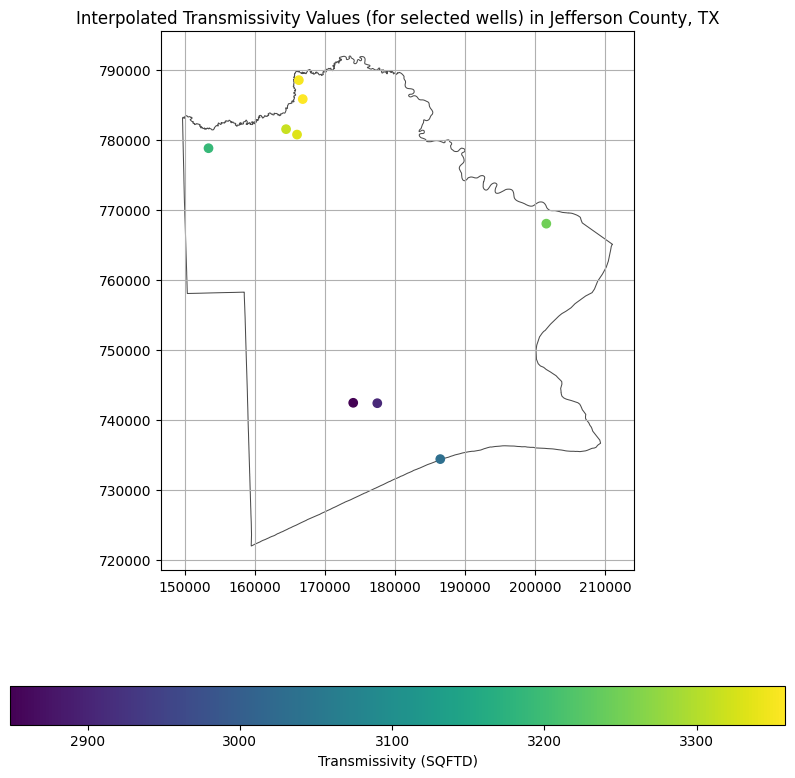

In [501]:
# Plotting the map for all the 9 selected wells
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Jefferson County boundary
Jeff.plot(ax=ax, color='none', edgecolor='black', alpha=0.7, linewidth=0.75)

# Plot transmissivity values as a color-coded layer
# Assuming 'Transmissivity' is the column name in Tvalues containing the interpolated transmissivity values
Tvalues.plot(column='TSQFTD', ax=ax, cmap='viridis', legend=True,
             legend_kwds={'label': "Transmissivity (SQFTD)", 'orientation': "horizontal"})

# Add title and grid
plt.title("Interpolated Transmissivity Values (for selected wells) in Jefferson County, TX")
plt.grid(visible=True)

# Display the map
plt.show()

<h4> <font color='green'> Step 3 Selecting the Well Location (lat-lon coordinates) & converting to AEA projection

In [502]:
# Select a specific well by its StateWellNumber (replace with your actual well ID)
selected_id = 6424502
df = pd.read_csv('JGCMeanWL.csv')

# Filter the DataFrame for the selected well
selected_well = df[df['StateWellNumber'] == selected_id]

# Create geometry from 'LongitudeDD' and 'LatitudeDD' columns for the selected well
geometry = [Point(xy) for xy in zip(selected_well['LongitudeDD'], selected_well['LatitudeDD'])]

# Create a GeoDataFrame with the selected well's geometry
gdf = gpd.GeoDataFrame(selected_well, geometry=geometry)

# Set the initial CRS to WGS84 (EPSG:4326) - assuming data is in lat-lon
gdf.set_crs(epsg=4326, inplace=True)

# Convert the CRS to Albers Equal Area Conic (AEA) for CONUS, NAD 83 (2011), EPSG:6350
gdf = gdf.to_crs(epsg=6350)

# Extract the transformed coordinates (X, Y) and add them as new columns
gdf['LON6350'] = gdf.geometry.x
gdf['LAT6350'] = gdf.geometry.y

# Print the result
print(gdf[['StateWellNumber', 'LongitudeDD', 'LatitudeDD', 'LON6350', 'LAT6350']])

     StateWellNumber  LongitudeDD  LatitudeDD        LON6350        LAT6350
184          6424502   -94.072778   29.667778  186485.560801  734412.407858


<h4> <font color='green'>
Step 4 Extract Transmissivity values at the well (from interpolated T gpkg file)

In [503]:
# Load the transmissivity values GeoDataFrame
Tvalues = gpd.read_file("pwells2.gpkg")  # Adjust the path as needed

# Select the well based on the StateWellNumber or Latitude/Longitude (replace selected_id with your well ID)
selected_id = 6424502  # Example well ID (you can replace this with the actual well number)

# Filter the Tvalues GeoDataFrame for the specific well
selected_well = Tvalues[Tvalues['StateWellNumber'] == selected_id]

# If you want to select by Latitude and Longitude, use the following (for a specific well with known coordinates):
# selected_well = Tvalues[(Tvalues['LongitudeDD'] == well_lon) & (Tvalues['LatitudeDD'] == well_lat)]

# Extract the Transmissivity (TSQFTD) for the selected well
transmissivity_value = selected_well['TSQFTD'].values[0]  # Extracting the value from the series

# Print the Transmissivity value for the selected well
print(f"Transmissivity (TSQFTD) at the well {selected_id}: {transmissivity_value}")


Transmissivity (TSQFTD) at the well 6424502: 3032


<h4> <font color='green'> Step 5 Obtain the mean water levels (computed earlier) for wells in a gpkg file

In [504]:
# Load the GeoPackage containing the well data
mean_water_levels_gdf = gpd.read_file("pwells2.gpkg")

# Assuming the columns containing the water levels and depth are named 'WaterElevation' and 'DepthFromLSD'
# If the column names are different, adjust accordingly

# Extract just the relevant columns: StateWellNumber, WaterElevation, DepthFromLSD
mean_water_levels = mean_water_levels_gdf[['StateWellNumber', 'WaterElevation', 'DepthFromLSD']]

# If you only need the well you're interested in, filter the well by its StateWellNumber
# Example for selecting a specific well (e.g., 6424502):
selected_selected_id = 6424502
selected_well = mean_water_levels[mean_water_levels['StateWellNumber'] == selected_selected_id]

# Print the selected well's data
print(selected_well)

   StateWellNumber  WaterElevation  DepthFromLSD
8          6424502             2.0           3.0


<h4> <font color='green'>Step 6 Convert the meam water levels file to AEA projection and compute X and Y coordinates

In [505]:
mean_water_levels_gdf = mean_water_levels_gdf.to_crs("EPSG:6350")  # AEA projection
# Compute X and Y coordinates in AEA
mean_water_levels_gdf['X'] = mean_water_levels_gdf.geometry.x
mean_water_levels_gdf['Y'] = mean_water_levels_gdf.geometry.y
print(mean_water_levels_gdf[['X', 'Y']].head())

               X              Y
0  166834.846987  785849.276114
1  166277.793526  788553.162588
2  153372.144389  778829.427503
3  166018.090732  780777.008066
4  164452.693490  781550.465279


<h4> <font color='green'>Step 7 Compute the regional groundwater flow using linear regression of Hydraulic Head (from MSL) against X and Y

In [506]:
# Calculate Hydraulic Head
Tvalues['Hydraulic_Head'] = Tvalues['WaterElevation'] + Tvalues['DepthFromLSD']

In [507]:
# Merging mean_water_levels_gdf DataFrame with Tvalues
mean_water_levels_gdf = mean_water_levels_gdf.merge(Tvalues[['StateWellNumber', 'Hydraulic_Head']], on='StateWellNumber', how='left')
# Regression
X = mean_water_levels_gdf[['X', 'Y']]
X = sm.add_constant(X)
y = mean_water_levels_gdf['Hydraulic_Head']
# Fit linear regression model
model = sm.OLS(y, X).fit()
gradient_x, gradient_y = model.params['X'], model.params['Y']
# Output gradients
print(f"Gradient with respect to X: {gradient_x}")
print(f"Gradient with respect to Y: {gradient_y}")

Gradient with respect to X: -0.00036531043634435847
Gradient with respect to Y: 0.0005061968739646671


<h4> <font color='green'> Step 8 Using the coefficients of X and Y to obtain the gradients along X and Y axis and compute resultant gradient

In [508]:
# Compute the resultant gradient
resultant_gradient = np.sqrt(gradient_x**2 + gradient_y**2)
# Print the resultant gradient without scientific notation
print(f"Resultant Hydraulic Gradient: {resultant_gradient:.8f}")

Resultant Hydraulic Gradient: 0.00062425


<h4> <font color='green'> Step 9, 10 Capture Zone Calculation and Polygon Export in AEA Projection

In [509]:
# Given parameters
Pop = 20000
pcu = 135  # gallons/d/capita
conversion_factor = 0.0037854117840007  # From gallons to cubic meters
Q = Pop * pcu * conversion_factor  # Pumping rate in m³/day
print(f"Pumping Rate (Q): {Q} m³/day")

# Using transmissivity (T) from Tvalues
T = Tvalues['TSQFTD'].mean() * 0.0929  # Convert transmissivity to m²/day
print(f"Transmissivity (T): {T} m²/day")

# Direction of flow
theta = np.arctan2(gradient_y, gradient_x)  # Angle in radians
theta_deg = np.degrees(theta)  # Convert to degrees
print(f"Direction of Flow: {theta} radians, {theta_deg} degrees")

# Output the results
print(f"Resultant Hydraulic Gradient Magnitude: {resultant_gradient}")
print(f"Flow Direction: {theta_deg} degrees")

# Stagnation point and capture zone dimensions
xs = -Q / (2 * np.pi * T * resultant_gradient)  # Stagnation point

# Calculate the y-value at the extraction well
Y0 = (Q/(4*T*i)), -(Q/(4*T*i))

# Calculate the maximum width of the capture zone along the Y-axis
y_max = (Q/(2*T*i)), -(Q/(2*T*i))

print(f"Stagnation point (xs): {xs} m")
print(f"Maximum width of the capture zone (y_max): {y_max} m")
print(f"Y-value at the extraction well (Y_at the well): {Y0} m")

# Creating Capture Zone Polygon
from shapely.geometry import Polygon
capture_zone_points = list(zip(x_vals, y_vals))
capture_zone_polygon = Polygon(capture_zone_points)

# Save polygon to GeoPackage
capture_zone_gdf = gpd.GeoDataFrame({'geometry': [capture_zone_polygon]}, crs="EPSG:6350")
output_file = "combined_capture_zone.gpkg"
capture_zone_gdf.to_file(output_file, driver="GPKG")
print(f"Capture zone polygon exported to '{output_file}'")

Pumping Rate (Q): 10220.611816801891 m³/day
Transmissivity (T): 295.0194333333333 m²/day
Direction of Flow: 2.1959226874303246 radians, 125.81710212678307 degrees
Resultant Hydraulic Gradient Magnitude: 0.0006242491410596467
Flow Direction: 125.81710212678307 degrees
Stagnation point (xs): -8832.5976514734 m
Maximum width of the capture zone (y_max): (27748.42389398329, -27748.42389398329) m
Y-value at the extraction well (Y_at the well): (13874.211946991645, -13874.211946991645) m
Capture zone polygon exported to 'combined_capture_zone.gpkg'


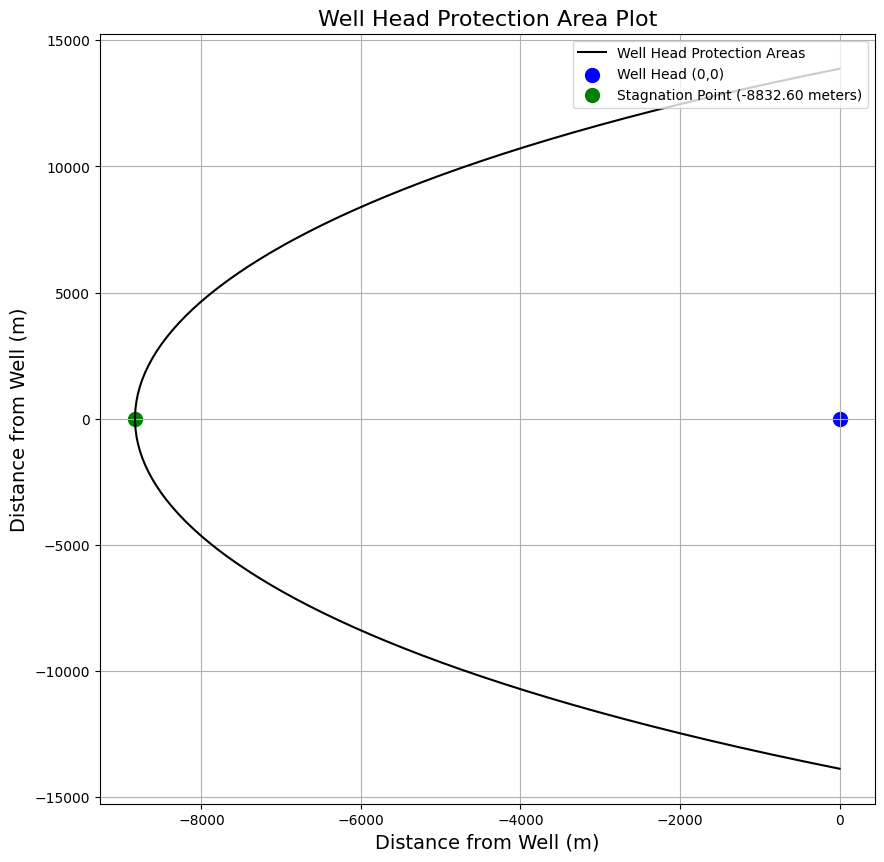

In [510]:
# Constants
T = 295.0194333333333  # Transmissivity in m²/day
i = 0.0006242491410596467  # Hydraulic gradient
Q = 10220.611816801891  # Flow rate in cubic meters per day


# Define y range in meters and convert to kilometers for plotting
y = np.linspace(-13874.211946991645, 13874.211946991645, 100)  # y in meters

# Calculate x using the boundary equation
x = -y / np.tan((2 * np.pi * T * i * y) / Q)  # x in meters

# Plotting with customizations
plt.figure(figsize=(10, 10))
plt.plot(x, y, label='Well Head Protection Areas', linestyle='-', color='black')  # Plot the boundary line
plt.xlabel('Distance from Well (m)', fontsize=14)  # X axis label
plt.ylabel('Distance from Well (m)', fontsize=14)  # Y axis label
plt.title('Well Head Protection Area Plot', fontsize=16)  # Title

# Marking the Well Head at (0,0)
plt.scatter(0, 0, color='blue', s=100, marker='o', label='Well Head (0,0)')  # Mark well head

# Marking the Stagnation Point (example -8,000 meters in the negative x-direction)
stagnation_point_x = -8832.5976514734
plt.scatter(stagnation_point_x, 0, color='green', s=100, marker='o', label='Stagnation Point (-8832.60 meters)')

# Add grid and legend for better readability
plt.grid(True)
plt.legend(loc='upper right')
plt.show()


<h4> <font color='green'> Step 11 Transform the coordinates obtained in the above step such that X-axis is oriented along the groundwater flow directione.

In [511]:
# Constants
theta_deg = 125.81710212678307  # Direction of flow in degrees from the mini project file
theta_rad = np.radians(theta_deg)  # Convert to radians

# Load the capture zone GeoPackage
capture_zone_gdf = gpd.read_file("combined_capture_zone.gpkg")
capture_zone_gdf = capture_zone_gdf.to_crs(epsg=6350)  # Ensure CRS matches EPSG:6350

# Function to rotate coordinates
def rotate_coordinates(x, y, angle):
    x_rot = x * np.cos(angle) + y * np.sin(angle)
    y_rot = -x * np.sin(angle) + y * np.cos(angle)
    return x_rot, y_rot

# Extract and transform capture zone polygon coordinates
polygon = capture_zone_gdf.geometry[0]
coords = np.array(polygon.exterior.coords)
x, y = coords[:, 0], coords[:, 1]
x_rot, y_rot = rotate_coordinates(x, y, theta_rad)

# Create the rotated polygon
rotated_polygon = Polygon(zip(x_rot, y_rot))
capture_zone_gdf['geometry'] = [rotated_polygon]

# Save the transformed polygon
transformed_file = "transformed_combined_capture_zone.gpkg"
capture_zone_gdf.to_file(transformed_file, driver="GPKG")
print(f"Rotated capture zone saved to {transformed_file}")

Rotated capture zone saved to transformed_combined_capture_zone.gpkg


<h4> <font color='green'> Step 12 Create a shapely polygon (object) of the capture zone. Export to a gpkg file

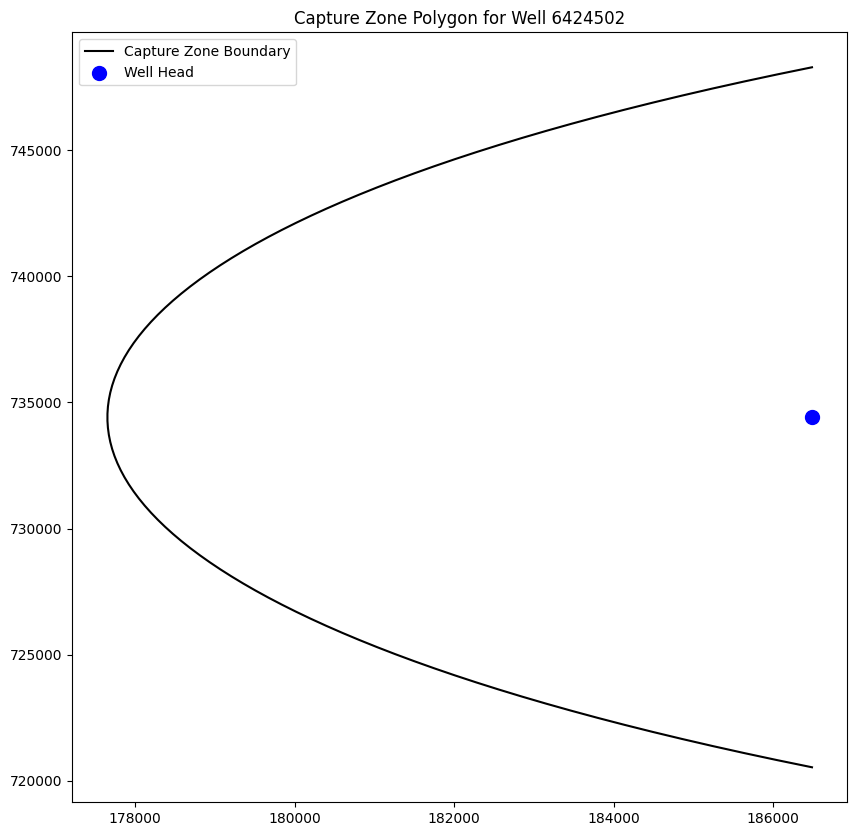

Capture zone polygon exported to capture_zone_6424502.gpkg


In [512]:
# Constants
T = 295.0194333333333  # Transmissivity in m²/day
i = 0.0006242491410596467  # Hydraulic gradient
Q = 10220.611816801891  # Flow rate in cubic meters per day


# Define y range in meters
y = np.linspace(-13874.211946991645, 13874.211946991645, 100)  # y in meters

# Calculate x using the boundary equation
x = -y / np.tan((2 * np.pi * T * i * y) / Q)  # x in meters

# Load GeoPackage file for selected well data
selected_well = gpd.read_file('pwells2.gpkg')
selected_well = selected_well.to_crs(epsg=6350)  # Ensure CRS matches EPSG:6350

# Select Well ID
selected_well = selected_well[selected_well['StateWellNumber'] == selected_id]
# Get the coordinates for the selected well
well_point = selected_well.geometry.iloc[0]
well_x, well_y = well_point.x, well_point.y

# Calculate capture zone coordinates relative to the well location
capture_zone_x = x + well_x
capture_zone_y = y + well_y

# Combine x and y into points and create a Polygon
capture_zone_boundary_points = list(zip(capture_zone_x, capture_zone_y))
capture_zone_polygon = Polygon(capture_zone_boundary_points)

# Plotting for visualization (optional)
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(capture_zone_x, capture_zone_y, label='Capture Zone Boundary', color='black')
plt.scatter(well_x, well_y, color='blue', s=100, label='Well Head')
plt.title("Capture Zone Polygon for Well 6424502")
plt.legend()
plt.show()

# Create a GeoDataFrame for export
capture_zone_gdf = gpd.GeoDataFrame({'selected_id': [selected_id], 'geometry': [capture_zone_polygon]}, crs='EPSG:6350')

# Export to a GPKG file
capture_zone_gdf.to_file('capture_zone_6424502.gpkg', layer='CaptureZone', driver='GPKG')

print("Capture zone polygon exported to capture_zone_6424502.gpkg")

<h4> <font color='green'> Step 13 Overlay the capture zone polygon onto the Jefferson County Map; Embellish the plot as appropriate.

C:\Users\aksha\AppData\Local\Temp\ipykernel_21828\2689049531.py:56: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')


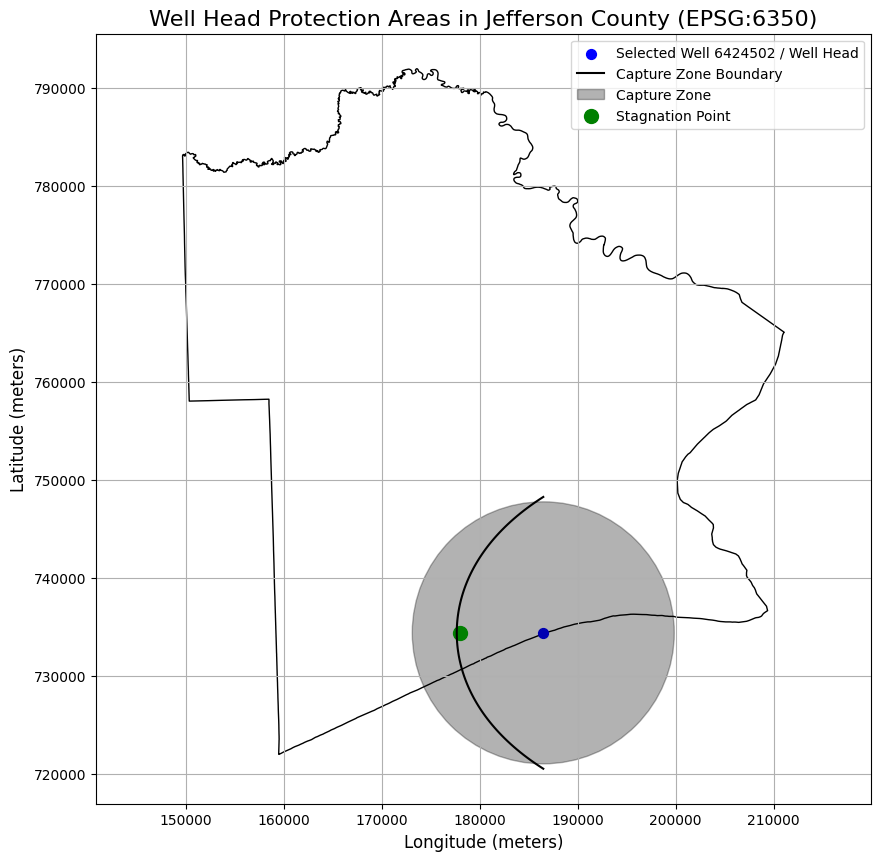

In [513]:
# Constants
T = 295.0194333333333  # Transmissivity in m²/day
i = 0.0006242491410596467  # Hydraulic gradient
Q = 10220.611816801891  # Flow rate in cubic meters per day

# Define the range for y-values in meters
y = np.linspace(-13874.211946991645, 13874.211946991645, 100)

# Calculate x-coordinates based on the boundary formula
x = -y / np.tan((2 * np.pi * T * i * y) / Q)

# Load spatial data for wells and Jefferson County
well_data = gpd.read_file('pwells2.gpkg')
county_boundary = gpd.read_file('Jefferson_6350.gpkg')

# Reproject both GeoDataFrames to the Albers Equal Area projection (EPSG:6350)
well_data = well_data.to_crs(epsg=6350)
county_boundary = county_boundary.to_crs(epsg=6350)

# Filter the well data to select the well with the specified StateWellNumber
specific_well = well_data[well_data['StateWellNumber'] == selected_id]

# Retrieve the coordinates of the selected well
well_location = specific_well.geometry.iloc[0]
well_x, well_y = well_location.x, well_location.y

# Adjust capture zone coordinates relative to the well's position
capture_zone_x = x + well_x
capture_zone_y = y + well_y

# Visualization setup
fig, ax = plt.subplots(figsize=(10, 10))

# Display the Jefferson County map
county_boundary.plot(ax=ax, color='none', edgecolor='black', label='Jefferson County')

# Highlight the selected well
specific_well.plot(ax=ax, color='blue', markersize=50, label=f'Selected Well {selected_id} / Well Head')

# Overlay the calculated capture zone boundary
ax.plot(capture_zone_x, capture_zone_y, label='Capture Zone Boundary', color='black')

# Add a circular representation of the capture zone for context
zone_radius = 13374.93170104851  # Maximum extent for visualization
circle_patch = plt.Circle((well_x, well_y), zone_radius, color='black', alpha=0.3, label='Capture Zone', zorder=1)
ax.add_patch(circle_patch)

# Mark the well's location and the stagnation point

ax.scatter(well_x - 8514.74597495, well_y, color='green', s=100, label='Stagnation Point')

# Add a title, axis labels, and legend to the plot
plt.title('Well Head Protection Areas in Jefferson County (EPSG:6350)', fontsize=16)
plt.xlabel('Longitude (meters)', fontsize=12)
plt.ylabel('Latitude (meters)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True)

# Maintain equal aspect ratio for accurate spatial representation
plt.axis('equal')

# Display the map
plt.show()
